## Análisis estadístico de señales 
## ECG: análisis en el dominio del tiempo

Sofía Cedeño Vargas - Mariana Paulina Vargas


1. Importación de librerías y datos

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.signal import find_peaks

#Cargar archivo .mat
data = sio.loadmat("signals.mat")

#Frecuencia de muestreo
Fs = float(data["Fs"].squeeze())

#ECG sin filtrar y filtrado
ecg = np.squeeze(data["ECG_asRecording"]).astype(float)
ecg_filtered = np.squeeze(data["ECG_filtered"]).astype(float)

print(f"Frecuencia de muestreo: {Fs:.0f} Hz")
print(f"Número de muestras ECG: {len(ecg)}")
print(f"Número de muestras ECG filtrado: {len(ecg_filtered)}")

Frecuencia de muestreo: 1024 Hz
Número de muestras ECG: 30720
Número de muestras ECG filtrado: 30720


2. Implementación de la función RMS

Para una señal discreta \(x[n]\) con \(N\) muestras:

\[
RMS = \sqrt{\frac{1}{N}\sum_{n=1}^{N}x[n]^2}
\]

El RMS siempre es no negativo y representa una medida de la magnitud efectiva de la señal.

In [2]:
def calcular_rms(x):
    #Convertir la entrada a arreglo numérico
    x = np.asarray(x, dtype=float)

    #Calcular valor cuadrático medio
    return np.sqrt(np.mean(x**2))

#Prueba rápida de la función
print("RMS del ECG sin filtrar:", calcular_rms(ecg))
print("RMS del ECG filtrado:", calcular_rms(ecg_filtered))

RMS del ECG sin filtrar: 4392.968293749072
RMS del ECG filtrado: 286.305571152495


3. Duración de la señal y vector de tiempo

In [3]:
#Duración total del registro
N = len(ecg)
duracion = N / Fs

#Vector de tiempo: una posición temporal por muestra
t = np.arange(N) / Fs

print(f"Número de muestras: {N}")
print(f"Frecuencia de muestreo: {Fs:.0f} Hz")
print(f"Duración de la señal: {duracion:.2f} s")
print(f"Tiempo inicial: {t[0]:.6f} s")
print(f"Tiempo final de la última muestra: {t[-1]:.6f} s")

Número de muestras: 30720
Frecuencia de muestreo: 1024 Hz
Duración de la señal: 30.00 s
Tiempo inicial: 0.000000 s
Tiempo final de la última muestra: 29.999023 s


Resultado

El registro ECG contiene **30720 muestras** y fue adquirido a **1024 Hz**, por lo que:

La duración del registro es **30 s**. 

4. ECG sin filtrar y ECG filtrado

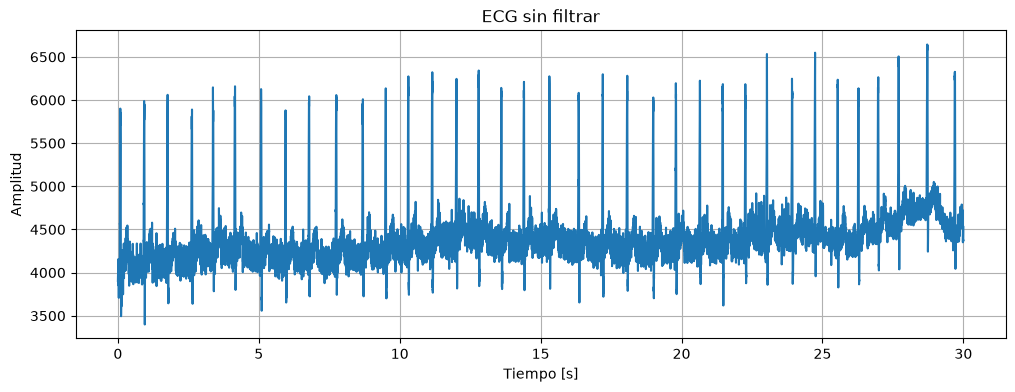

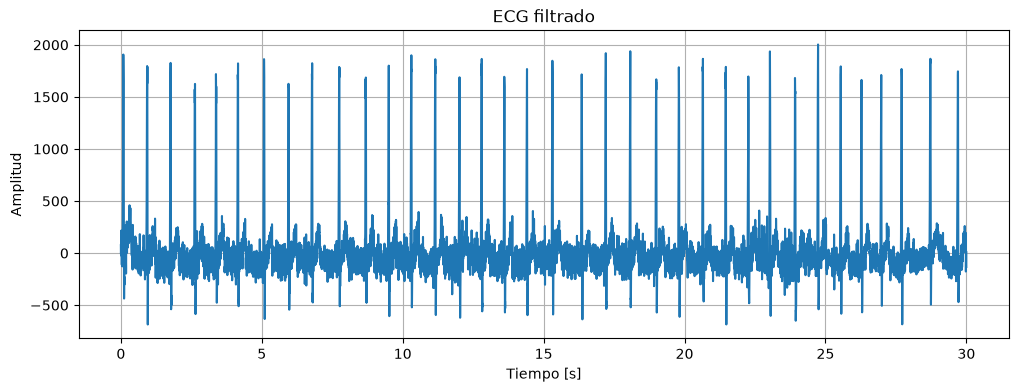

In [4]:
plt.figure(figsize=(12, 4))
plt.plot(t, ecg)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG sin filtrar")
plt.grid(True)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, ecg_filtered)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("ECG filtrado")
plt.grid(True)
plt.show()

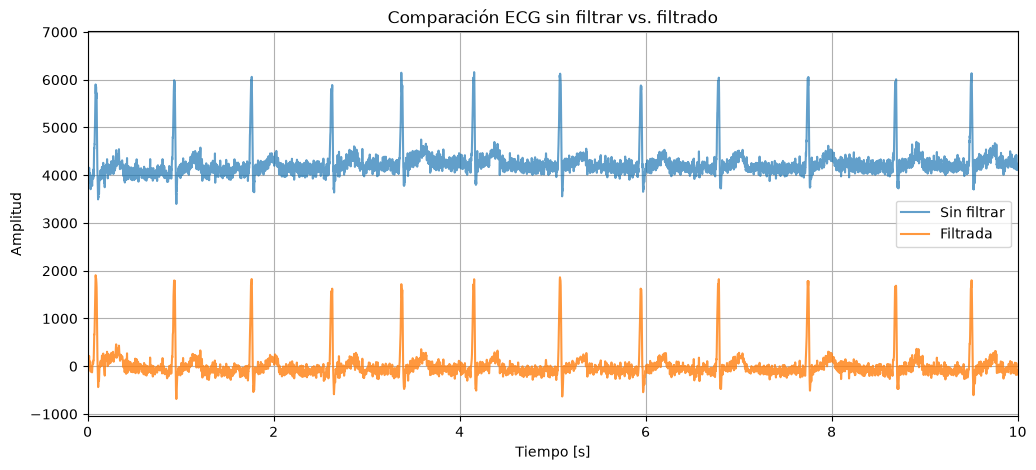

In [5]:
#Comparación en los primeros 10 segundos
plt.figure(figsize=(12, 5))
plt.plot(t, ecg, label="Sin filtrar", alpha=0.7)
plt.plot(t, ecg_filtered, label="Filtrada", alpha=0.8)
plt.xlim(0, 10)
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Comparación ECG sin filtrar vs. filtrado")
plt.legend()
plt.grid(True)
plt.show()

Análisis

Al comparar ambas señales se observa que el filtrado reduce componentes no deseadas presentes en el registro original. En particular, la señal filtrada queda centrada alrededor de valores cercanos a cero, mientras que la señal sin filtrar presenta un nivel de referencia elevado.

También se observa una reducción del ruido de alta frecuencia y una conservación clara de los complejos QRS, que son los eventos de mayor amplitud del ECG.

**Comportamiento esperado del filtro:** debe conservar las componentes de frecuencia relevantes para la morfología del ECG y atenuar componentes no deseadas, como deriva de línea base y ruido de alta frecuencia. Se pide recordar las frecuencias de interés del ECG, pero  no se proporcionan los valores de corte específicos del filtro usado; por eso no se debe afirmar un tipo o frecuencia de corte concreta sin consultar el diseño del filtro.

5. Selección de un ciclo cardiaco

Para seleccionar los ciclos de forma reproducible se detectan los picos R en la señal filtrada. Cada intervalo entre dos picos R consecutivos se toma como un ciclo R–R.

Esto permite seleccionar un ciclo completo y utilizar exactamente los mismos límites temporales en la señal sin filtrar y en la señal filtrada.


In [6]:
#Detección de picos R en la señal filtrada
picos_R, propiedades = find_peaks(
    ecg_filtered,
    distance=int(0.5 * Fs),
    prominence=500
)

print("Número de picos R detectados:", len(picos_R))
print("Primeros picos R (muestras):", picos_R[:10])

#Primer ciclo completo: entre el primer y segundo pico R
inicio = picos_R[0]
fin = picos_R[1]

ciclo_raw = ecg[inicio:fin]
ciclo_filtered = ecg_filtered[inicio:fin]
t_ciclo = np.arange(inicio, fin) / Fs

print(f"Inicio del ciclo: {inicio} muestras = {inicio/Fs:.4f} s")
print(f"Fin del ciclo: {fin} muestras = {fin/Fs:.4f} s")
print(f"Duración del ciclo: {(fin-inicio)/Fs:.4f} s")

Número de picos R detectados: 36
Primeros picos R (muestras): [  88  952 1806 2693 3454 4256 5201 6090 6950 7936]
Inicio del ciclo: 88 muestras = 0.0859 s
Fin del ciclo: 952 muestras = 0.9297 s
Duración del ciclo: 0.8438 s


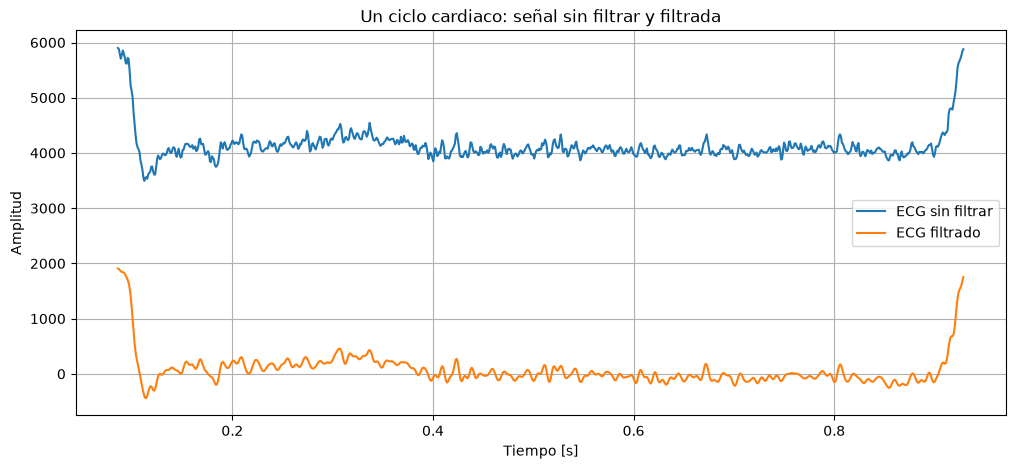

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(t_ciclo, ciclo_raw, label="ECG sin filtrar")
plt.plot(t_ciclo, ciclo_filtered, label="ECG filtrado")
plt.xlabel("Tiempo [s]")
plt.ylabel("Amplitud")
plt.title("Un ciclo cardiaco: señal sin filtrar y filtrada")
plt.legend()
plt.grid(True)
plt.show()


6. Promedio, RMS, varianza y desviación estándar del ciclo

In [8]:
def estadisticas_senal(x):
    x = np.asarray(x, dtype=float)
    return {
        "Promedio": np.mean(x),
        "RMS": calcular_rms(x),
        "Varianza": np.var(x),
        "Desviación estándar": np.std(x)
    }

estadisticas_raw = estadisticas_senal(ciclo_raw)
estadisticas_filtered = estadisticas_senal(ciclo_filtered)

print("CICLO SIN FILTRAR")
for nombre, valor in estadisticas_raw.items():
    print(f"{nombre}: {valor:.4f}")

print("\nCICLO FILTRADO")
for nombre, valor in estadisticas_filtered.items():
    print(f"{nombre}: {valor:.4f}")


CICLO SIN FILTRAR
Promedio: 4129.0676
RMS: 4139.9580
Varianza: 90052.8583
Desviación estándar: 300.0881

CICLO FILTRADO
Promedio: 74.0100
RMS: 319.6276
Varianza: 96684.3149
Desviación estándar: 310.9410


Resultados del ciclo seleccionado

Para el primer intervalo R–R completo detectado:

| Medida | Sin filtrar | Filtrado |
|---|---:|---:|
| Promedio | 4129.0676 | 74.0100 |
| RMS | 4139.9580 | 319.6276 |
| Varianza | 90052.8583 | 96684.3149 |
| Desviación estándar | 300.0881 | 310.9410 |

Interpretación

El promedio cambia de forma marcada después del filtrado porque el registro original presenta un nivel de línea base elevado, mientras que el filtrado elimina gran parte de ese componente. Por esta razón, el RMS del registro sin filtrar está fuertemente influenciado por el nivel DC/desplazamiento de la señal.

La varianza y la desviación estándar describen la dispersión de las muestras alrededor de su promedio. En este ciclo, sus valores son del mismo orden antes y después del filtrado, aunque pueden cambiar debido a la eliminación de componentes de ruido.


7. Extracción de 15 ciclos de la señal filtrada

In [9]:
#Extraer los primeros 15 ciclos R-R completos
n_ciclos = 15
ciclos = []
estadisticas_15 = []

for i in range(n_ciclos):
    a = picos_R[i]
    b = picos_R[i + 1]
    ciclo = ecg_filtered[a:b]

    ciclos.append(ciclo)
    estadisticas_15.append({
        "Ciclo": i + 1,
        "Inicio [s]": a / Fs,
        "Fin [s]": b / Fs,
        "Duración [s]": (b - a) / Fs,
        "Promedio": np.mean(ciclo),
        "Varianza": np.var(ciclo),
        "Desv. estándar": np.std(ciclo),
        "RMS": calcular_rms(ciclo)
    })

import pandas as pd
tabla_15 = pd.DataFrame(estadisticas_15)
tabla_15


,Ciclo,Inicio [s],Fin [s],Duración [s],Promedio,Varianza,Desv. estándar,RMS
0,1,0.085938,0.929688,0.843750,74.009958,96684.314882,310.941015,319.627578
1,2,0.929688,1.763672,0.833984,-1.462578,104790.465489,323.713555,323.716859
2,3,1.763672,2.629883,0.866211,-10.433000,82451.251079,287.143259,287.332731
3,4,2.629883,3.373047,0.743164,-20.975178,46839.019694,216.423242,217.437296
4,5,3.373047,4.156250,0.783203,40.871105,114850.020065,338.895294,341.350944
5,6,4.156250,5.079102,0.922852,-27.943734,58147.589512,241.138113,242.751811
6,7,5.079102,5.947266,0.868164,0.430787,77707.281202,278.760258,278.760590
7,8,5.947266,6.787109,0.839844,21.407853,100268.181528,316.651514,317.374349
8,9,6.787109,7.750000,0.962891,-10.175290,71784.955786,267.927146,268.120294
9,10,7.750000,8.692383,0.942383,8.812103,68481.059763,261.688861,261.837188


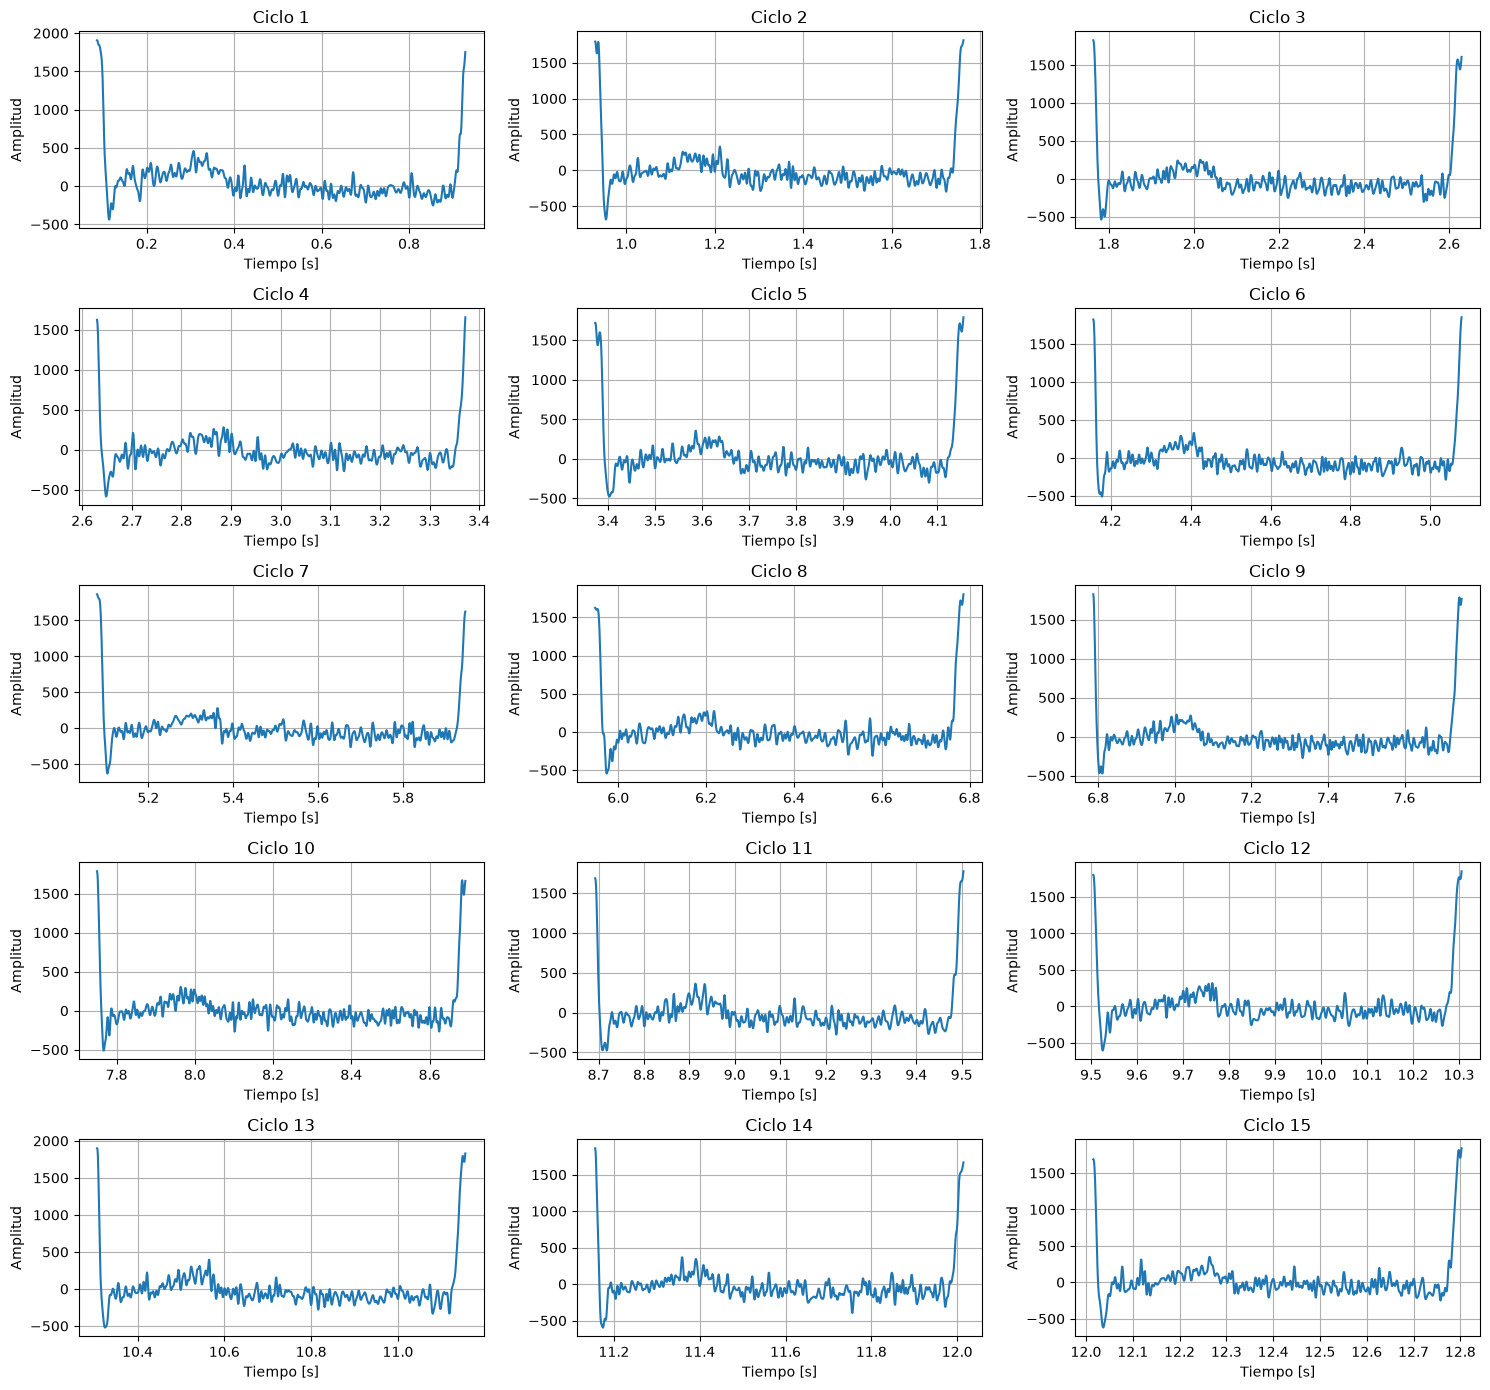

In [10]:
#Graficar los 15 ciclos en función del tiempo real
fig, axes = plt.subplots(5, 3, figsize=(15, 14))
axes = axes.ravel()

for i, ciclo in enumerate(ciclos):
    a = picos_R[i]
    b = picos_R[i + 1]
    t_local = np.arange(a, b) / Fs

    axes[i].plot(t_local, ciclo)
    axes[i].set_title(f"Ciclo {i+1}")
    axes[i].set_xlabel("Tiempo [s]")
    axes[i].set_ylabel("Amplitud")
    axes[i].grid(True)

plt.tight_layout()
plt.show()


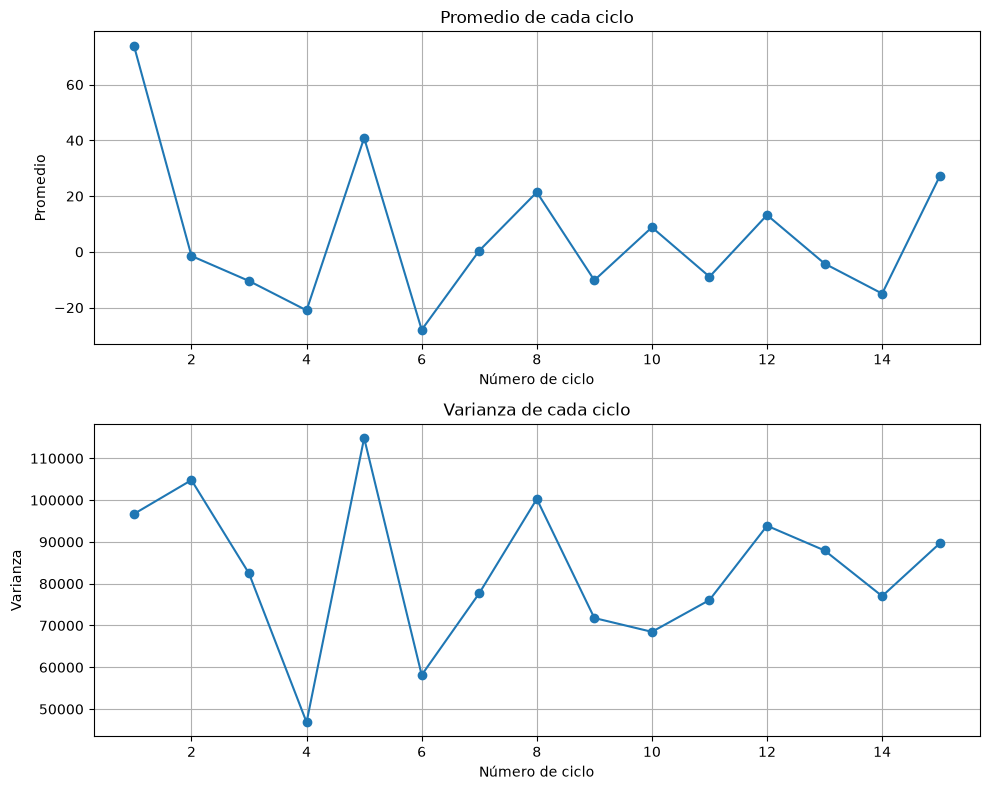

In [11]:
#Comparación gráfica de promedio y varianza de los 15 ciclos
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

axes[0].plot(tabla_15["Ciclo"], tabla_15["Promedio"], marker="o")
axes[0].set_xlabel("Número de ciclo")
axes[0].set_ylabel("Promedio")
axes[0].set_title("Promedio de cada ciclo")
axes[0].grid(True)

axes[1].plot(tabla_15["Ciclo"], tabla_15["Varianza"], marker="o")
axes[1].set_xlabel("Número de ciclo")
axes[1].set_ylabel("Varianza")
axes[1].set_title("Varianza de cada ciclo")
axes[1].grid(True)

plt.tight_layout()
plt.show()


Análisis gráfico y estadístico de los 15 ciclos

La comparación debe hacerse observando dos aspectos:

1. **Morfología:** si las formas de los ciclos son visualmente similares o presentan cambios importantes.
2. **Estadísticos:** si los promedios y las varianzas permanecen aproximadamente constantes.

En este registro, los ciclos presentan una morfología general semejante, aunque existen variaciones en amplitud, duración y ruido. Los valores de promedio y varianza tampoco son exactamente iguales entre ciclos.

**Conclusión preliminar:** la señal puede tratarse como aproximadamente estable durante el intervalo analizado para algunos propósitos descriptivos, pero no debe afirmarse rigurosamente que es estacionaria únicamente a partir de estas gráficas. La estacionariedad debe evaluarse estadística/probabilísticamente y posteriormente realizar pruebas t y Dickey-Fuller.

Por tanto, la conclusión definitiva sobre estacionariedad se realiza posteriormente.


8. Comparación estadística entre ciclos (prueba t / U de Mann-Whitney)

Para evaluar de forma más rigurosa si la señal puede considerarse estacionaria, se comparan dos pares de ciclos cualesquiera (no consecutivos) extraídos de la señal filtrada. Antes de aplicar la prueba de hipótesis se verifican los supuestos necesarios:

- **Normalidad** de cada grupo (prueba de Shapiro-Wilk).
- **Independencia**: se asume, dado que cada ciclo corresponde a un latido distinto y no hay traslape entre las muestras comparadas.
- **Homocedasticidad** (prueba de Levene), es decir, igualdad de varianzas entre los grupos.

Si se cumple la normalidad, se aplica una prueba t de Student (con o sin igualdad de varianzas, según el resultado de Levene). Si no se cumple, se aplica la alternativa no paramétrica: la prueba U de Mann-Whitney.

In [12]:
from scipy import stats

def comparar_ciclos(a, b, nombre_a, nombre_b, alpha=0.05):
    print(f"--- Comparación: {nombre_a} vs {nombre_b} ---")

    #Prueba de normalidad (Shapiro-Wilk) para cada ciclo
    sh_a = stats.shapiro(a)
    sh_b = stats.shapiro(b)
    print(f"Shapiro-Wilk {nombre_a}: W={sh_a.statistic:.4f}, p={sh_a.pvalue:.4g}")
    print(f"Shapiro-Wilk {nombre_b}: W={sh_b.statistic:.4f}, p={sh_b.pvalue:.4g}")
    normal_a = sh_a.pvalue > alpha
    normal_b = sh_b.pvalue > alpha

    #Prueba de homocedasticidad (Levene)
    lev = stats.levene(a, b)
    print(f"Levene (homocedasticidad): estadístico={lev.statistic:.4f}, p={lev.pvalue:.4g}")
    homoc = lev.pvalue > alpha

    #Independencia: se asume, ya que corresponden a ciclos cardiacos distintos y no traslapados

    #Selección de la prueba según los supuestos verificados
    if normal_a and normal_b:
        tt = stats.ttest_ind(a, b, equal_var=homoc)
        print(f"Normalidad OK en ambos ciclos -> prueba t de Student (equal_var={homoc}): "
              f"t={tt.statistic:.4f}, p={tt.pvalue:.4g}")
    else:
        mw = stats.mannwhitneyu(a, b, alternative="two-sided")
        print(f"No se cumple el supuesto de normalidad -> prueba U de Mann-Whitney: "
              f"U={mw.statistic:.1f}, p={mw.pvalue:.4g}")
    print()

#Comparación 1: ciclos no consecutivos, alejados en el registro
comparar_ciclos(ciclos[0], ciclos[7], "Ciclo 1", "Ciclo 8")

#Comparación 2: otro par de ciclos distintos
comparar_ciclos(ciclos[2], ciclos[11], "Ciclo 3", "Ciclo 12")


--- Comparación: Ciclo 1 vs Ciclo 8 ---
Shapiro-Wilk Ciclo 1: W=0.6182, p=6.428e-40
Shapiro-Wilk Ciclo 8: W=0.5384, p=1.412e-42
Levene (homocedasticidad): estadístico=2.5343, p=0.1116
No se cumple el supuesto de normalidad -> prueba U de Mann-Whitney: U=445000.0, p=1.162e-12

--- Comparación: Ciclo 3 vs Ciclo 12 ---
Shapiro-Wilk Ciclo 3: W=0.5641, p=2.975e-42
Shapiro-Wilk Ciclo 12: W=0.5646, p=5.772e-41
Levene (homocedasticidad): estadístico=0.4313, p=0.5114
No se cumple el supuesto de normalidad -> prueba U de Mann-Whitney: U=328708.0, p=0.0005079



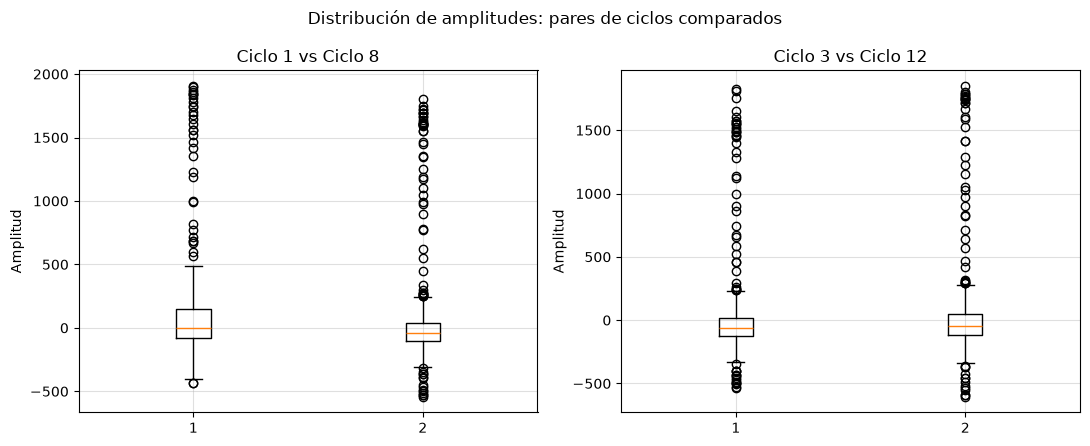

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].boxplot([ciclos[0], ciclos[7]], label=["Ciclo 1", "Ciclo 8"])
axes[0].set_title("Ciclo 1 vs Ciclo 8")
axes[0].set_ylabel("Amplitud")
axes[0].grid(True, alpha=0.4)

axes[1].boxplot([ciclos[2], ciclos[11]], label=["Ciclo 3", "Ciclo 12"])
axes[1].set_title("Ciclo 3 vs Ciclo 12")
axes[1].set_ylabel("Amplitud")
axes[1].grid(True, alpha=0.4)

plt.suptitle("Distribución de amplitudes: pares de ciclos comparados")
plt.tight_layout()
plt.show()


En ambos pares de ciclos comparados, la prueba de Shapiro-Wilk arroja valores p muy por debajo de 0.05, por lo que **no se cumple el supuesto de normalidad** (era esperable, ya que un ciclo cardiaco no sigue una distribución gaussiana: es una forma de onda estructurada con un pico agudo -complejo QRS- y segmentos casi planos). La prueba de Levene, en cambio, no muestra evidencia de diferencias significativas en la varianza entre los ciclos comparados (p > 0.05 en ambos casos), es decir, sí se cumple la homocedasticidad.

Como no se cumple la normalidad, se utiliza la prueba U de Mann-Whitney en lugar de la prueba t. En **ambas comparaciones** (Ciclo 1 vs. Ciclo 8, y Ciclo 3 vs. Ciclo 12) se obtiene un p-value muy inferior a 0.05, por lo que se **rechaza la hipótesis nula** de que las muestras provienen de la misma distribución: existe diferencia estadísticamente significativa entre las amplitudes de los ciclos comparados.

Esto indica que, muestra a muestra, la distribución de amplitudes **no es idéntica** de un ciclo a otro (lo cual es consistente con pequeñas variaciones de amplitud, ruido y morfología observadas en la Sección 7). Sin embargo, esto **no implica necesariamente que la señal sea no estacionaria en sentido amplio**: la prueba de Mann-Whitney es sensible a cualquier diferencia en la forma de la distribución (incluyendo diferencias de fase dentro del ciclo R-R), mientras que la estacionariedad en sentido débil solo exige que la media y la varianza globales se mantengan aproximadamente estables en el tiempo, algo que sí se observó de forma razonable en la Sección 7.

9. Prueba de Dickey-Fuller (estacionariedad)

Como verificación adicional y más formal de los resultados anteriores, se aplica la prueba aumentada de Dickey-Fuller (ADF), cuya hipótesis nula (H0) establece que la serie **tiene una raíz unitaria** (es decir, que es no estacionaria). Un p-value bajo (< 0.05) permite rechazar H0 y concluir que la serie es estacionaria en el sentido de esta prueba.

La prueba se aplica tanto sobre el ECG filtrado completo como sobre el segmento correspondiente a los 15 ciclos analizados en la Sección 7, para poder comparar directamente con esos resultados.

In [20]:
try:
    from statsmodels.tsa.stattools import adfuller
except ImportError:
    #Implementación equivalente al test aumentado de Dickey-Fuller (ADF),
    #usada únicamente si statsmodels no está disponible en el entorno.
    #Regresión: Δx_t = α + β·x_(t-1) + Σ γ_i·Δx_(t-i) + ε_t
    #El orden de rezago se elige minimizando el criterio de Akaike (AIC).
    def adfuller(x, maxlag=None, regression="c", autolag="AIC"):
        x = np.asarray(x, dtype=float)
        n = len(x)
        if maxlag is None:
            maxlag = min(int(np.ceil(12 * (n / 100.) ** 0.25)), 20)
        dy_full = np.diff(x)

        def fit(p):
            dep = dy_full[p:]
            reg_level = x[p:n - 1]
            regs = [np.ones(len(dep)), reg_level]
            for i in range(1, p + 1):
                regs.append(dy_full[p - i:n - 1 - i])
            X = np.column_stack(regs)
            beta, *_ = np.linalg.lstsq(X, dep, rcond=None)
            resid = dep - X @ beta
            nobs = len(dep); k = X.shape[1]
            rss = np.sum(resid ** 2)
            sigma2 = rss / (nobs - k)
            XtX_inv = np.linalg.inv(X.T @ X)
            se = np.sqrt(np.diag(XtX_inv) * sigma2)
            tstat_level = beta[1] / se[1]
            aic = nobs * np.log(rss / nobs) + 2 * k
            return tstat_level, aic

        best_aic, best = np.inf, None
        for p in range(0, maxlag + 1):
            try:
                tstat, aic = fit(p)
            except Exception:
                continue
            if not np.isfinite(tstat) or not np.isfinite(aic):
                continue
            if aic < best_aic:
                best_aic, best = aic, (p, tstat)
        p_used, adf_stat = best

        #Valores críticos (Fuller, 1976 / MacKinnon, modelo con constante)
        #e interpolación aproximada del p-value a partir de esa tabla
        cv_points = {0.01: -3.43, 0.025: -3.12, 0.05: -2.86, 0.10: -2.57,
                     0.90: -0.44, 0.95: -0.07, 0.975: 0.23, 0.99: 0.60}
        xs = np.array(sorted(cv_points.keys()))
        ys = np.array([cv_points[k_] for k_ in xs])
        order = np.argsort(ys)
        ys_sorted, xs_sorted = ys[order], xs[order]
        if adf_stat <= ys_sorted[0]:
            pval = xs_sorted[0]
        elif adf_stat >= ys_sorted[-1]:
            pval = xs_sorted[-1]
        else:
            pval = float(np.interp(adf_stat, ys_sorted, xs_sorted))
        crit = {"1%": -3.43, "5%": -2.86, "10%": -2.57}
        return adf_stat, pval, p_used, n, crit, None


#Se aplica la prueba sobre el ECG filtrado completo y sobre el segmento
#correspondiente a los 15 ciclos analizados en el punto anterior
segmentos = {
    "ECG filtrado completo": ecg_filtered,
    "Segmento de los 15 ciclos analizados": ecg_filtered[picos_R[0]:picos_R[15]]
}

for nombre, serie in segmentos.items():
    resultado = adfuller(serie)
    stat, pval = resultado[0], resultado[1]
    print(nombre)
    print(f"  ADF Statistic: {stat:.4f}")
    print(f"  p-value: {pval:.4f}")
    print(f"  Valores críticos: 1%=-3.43, 5%=-2.86, 10%=-2.57")
    print()

c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are n

ECG filtrado completo
  ADF Statistic: -11.8269
  p-value: 0.0000
  Valores críticos: 1%=-3.43, 5%=-2.86, 10%=-2.57



c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are n

Segmento de los 15 ciclos analizados
  ADF Statistic: -20.5114
  p-value: 0.0000
  Valores críticos: 1%=-3.43, 5%=-2.86, 10%=-2.57



c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  results[lag] = mod_instance.fit()
c:\Users\Lenovo\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\stattools\_stattools.py:149: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are n

En ambos segmentos evaluados, el estadístico ADF obtenido es mucho más negativo que el valor crítico al 1 % (-3.43), por lo que se **rechaza la hipótesis nula de raíz unitaria** con un nivel de significancia muy alto. Esto indica que, en el sentido de la prueba de Dickey-Fuller, **la señal ECG filtrada no presenta una tendencia estocástica (raíz unitaria)** y puede tratarse como estacionaria.

Este resultado **complementa** el análisis de la Sección 7 y de la prueba U de Mann-Whitney: si bien muestra a muestra las distribuciones de los ciclos individuales presentan diferencias significativas (posiblemente por variaciones de fase, ruido y pequeños cambios de morfología latido a latido), el comportamiento global de la señal (su media y varianza en el tiempo) no muestra una tendencia sistemática ni una deriva progresiva. En conjunto, esto sustenta la idea de que la señal ECG filtrada puede considerarse **aproximadamente estacionaria en sentido amplio** durante el intervalo analizado, aunque con variabilidad latido a latido propia de una señal biomédica.

10. Conclusiones

- Se implementó una función propia para el cálculo del valor RMS de una señal discreta, y se usó junto con las funciones `mean`, `var` y `std` de NumPy para caracterizar estadísticamente el registro ECG.
- El filtrado de la señal ECG elimina en gran medida la componente de línea base (offset/DC) y el ruido de alta frecuencia, preservando la morfología del complejo QRS, lo cual se refleja en un cambio marcado del promedio y del RMS entre la señal sin filtrar y la filtrada, mientras que la varianza y la desviación estándar (medidas de dispersión respecto a la propia media) se mantienen en órdenes de magnitud similares.
- Al analizar 15 ciclos cardiacos consecutivos, se observó que el promedio y la varianza de cada ciclo no son exactamente iguales, pero tampoco presentan una tendencia sistemática de crecimiento o decrecimiento, lo que sugiere una señal aproximadamente estable en ese intervalo.
- Las comparaciones no paramétricas (Mann-Whitney) entre pares de ciclos mostraron diferencias estadísticamente significativas en la distribución de amplitudes, lo cual es coherente con la variabilidad natural latido a latido de una señal biomédica, pero no necesariamente contradice la estacionariedad en sentido amplio de la señal completa.
- La prueba de Dickey-Fuller, tanto sobre el registro completo como sobre el segmento de 15 ciclos, rechazó de forma contundente la hipótesis de raíz unitaria, respaldando estadísticamente que la señal ECG filtrada puede tratarse como estacionaria durante el intervalo de registro analizado (30 s), un supuesto razonable para el análisis realizado en esta práctica, aunque estrictamente las bioseñales no lo sean en registros prolongados o ante cambios fisiológicos del sujeto.